# CSE 4095: Student Habits Regression and Model Error Assignment With Scikit-Learn 

# Part 0 — Start a Notebook and Inspect the Dataset

### Data-loading correction

Pandas' default CSV loading converted the text category `"None"` in `prior_programming_experience` to `NaN`. The dataset is now loaded with `keep_default_na=False` and `na_values=[""]`, so `"None"` remains a category and only the seven blank entries are missing. Results generated before this correction are no longer used.

In [60]:
import pandas as pd
import numpy as np

# Default read, kept only to compare missing-value handling below.
df_before = pd.read_csv('../assignment7/class1_student_habits.csv')

# Preserve the text category 'None'; treat only empty strings as missing.
df = pd.read_csv('../assignment7/class1_student_habits.csv', keep_default_na=False, na_values=[""])
df.head()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,quiz_average,exam_score
0,S001,1.3,7.7,71.8,8,Strong,No,0,67.0,64.6
1,S002,9.4,6.6,74.2,14,None,Yes,52,74.8,81.5
2,S003,11.2,6.1,70.3,15,Some,No,7,99.1,92.0
3,S004,10.8,7.6,77.1,16,Strong,No,12,86.4,100.0
4,S005,8.0,5.6,89.7,15,None,Yes,12,75.7,68.5


In [61]:
print('Missing values before the loading change:')
print(df_before.isna().sum())

print('\nMissing values after the loading change:')
print(df.isna().sum())

print('\nprior_programming_experience counts after the loading change:')
print(df['prior_programming_experience'].value_counts(dropna=False))

print('\nstudy_group counts after the loading change:')
print(df['study_group'].value_counts(dropna=False))

print('\nNumeric columns and missing-value checks after the loading change:')
print(df[['study_hours_per_week', 'sleep_hours_per_night']].dtypes)
print(df[['study_hours_per_week', 'sleep_hours_per_night']].isna().sum())

Missing values before the loading change:
student_id                       0
study_hours_per_week             9
sleep_hours_per_night           12
attendance_rate                  0
practice_problems_per_week       0
prior_programming_experience    95
study_group                      0
commute_minutes                  0
quiz_average                     0
exam_score                       0
dtype: int64

Missing values after the loading change:
student_id                       0
study_hours_per_week             9
sleep_hours_per_night           12
attendance_rate                  0
practice_problems_per_week       0
prior_programming_experience     7
study_group                      0
commute_minutes                  0
quiz_average                     0
exam_score                       0
dtype: int64

prior_programming_experience counts after the loading change:
prior_programming_experience
Some      107
None       88
Strong     48
NaN         7
Name: count, dtype: int64

study_group cou

In [62]:
print('Rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

Rows and columns: (250, 10)

Column names:
['student_id', 'study_hours_per_week', 'sleep_hours_per_night', 'attendance_rate', 'practice_problems_per_week', 'prior_programming_experience', 'study_group', 'commute_minutes', 'quiz_average', 'exam_score']

Data types:
student_id                       object
study_hours_per_week            float64
sleep_hours_per_night           float64
attendance_rate                 float64
practice_problems_per_week        int64
prior_programming_experience     object
study_group                      object
commute_minutes                   int64
quiz_average                    float64
exam_score                      float64
dtype: object

Missing values per column:
student_id                       0
study_hours_per_week             9
sleep_hours_per_night           12
attendance_rate                  0
practice_problems_per_week       0
prior_programming_experience     7
study_group                      0
commute_minutes                  0
quiz_average 

# Part 1 — Define the Regression Problem

This is a regression problem because the target, exam_score, is a continuous number (such as 82.7) and not a category. In Class 2 the model predicted a Yes/No label, so its output was a class. Converting to Yes/No throws away the exact score and the differences within each group, a 71 and a 98 would both become "Yes". A regression model should output a numerical prediction, such as 82.7, which can be compared to the actual score by how many points it is off.

# Part 2 — Inspect the Target

count     250.000000
mean       77.159600
median     76.950000
std        10.330499
min        51.400000
max       100.000000
Name: exam_score, dtype: float64


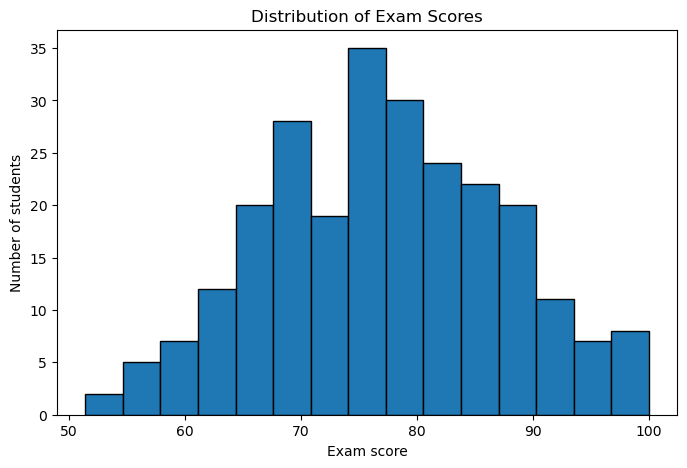

In [63]:
import matplotlib.pyplot as plt

# Summary statistics for the regression target
exam_summary = df['exam_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(exam_summary)

# Histogram of exam scores
plt.figure(figsize=(8, 5))
plt.hist(df['exam_score'], bins=15, edgecolor='black')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam score')
plt.ylabel('Number of students')
plt.show()

The 250 exam scores have a mean of 77.16, a median of 76.95, a standard deviation of 10.33, a minimum of 51.4, and a maximum of 100. The histogram is roughly symmetric with one broad peak around 75-80, and the near-equal mean and median agree with that. No values look extreme, the lowest score is about 2.5 SDs below the mean, and the maximum of 100 is a ceiling. Knowing the target first gives a yardstick for judging the model, since predicting the mean for everyone should give an RMSE near the SD of about 10.

# Part 3 — Explore One Relationship

Study hours and exam score have a correlation of 0.52 (241 students with both values), so higher study hours are associated with higher exam scores in this dataset. The relationship is positive and roughly linear, but with wide scatter. Several students don't follow the pattern, such as one at about 17.8 hours with a score near 65 and another at about 5 hours with a score near 96. This is an association only. It doesn't show that studying more causes higher scores.

Rows before removing missing values: 250
Rows used in analysis: 241
Correlation: 0.5155646432806654


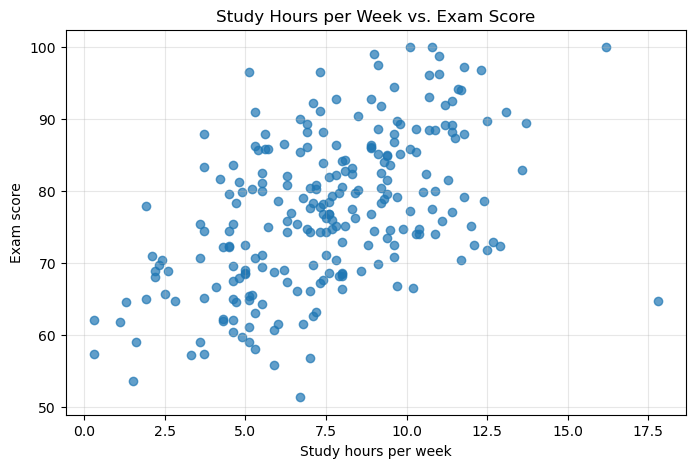

In [64]:
# Keep only rows with values for both variables used below
study_exam = df[['study_hours_per_week', 'exam_score']].dropna()

print('Rows before removing missing values:', len(df))
print('Rows used in analysis:', len(study_exam))

correlation = study_exam['study_hours_per_week'].corr(study_exam['exam_score'])
print('Correlation:', correlation)

plt.figure(figsize=(8, 5))
plt.scatter(study_exam['study_hours_per_week'], study_exam['exam_score'], alpha=0.7)
plt.title('Study Hours per Week vs. Exam Score')
plt.xlabel('Study hours per week')
plt.ylabel('Exam score')
plt.grid(alpha=0.3)
plt.show()

# Part 4 — Choose the Features

study_hours_per_week
sleep_hours_per_night
attendance_rate
practice_problems_per_week
prior_programming_experience
study_group
commute_minutes

# Part 5 — Create Training and Test Sets

The training set is where the model learns, including the imputation values, scaling statistics, and coefficients. The test set is held back to estimate performance on students the model hasn't seen. Training on the test set would make the score reflect memorization and look better than it should. All experiments use the same split (80/20, random_state=42) so that differences in the results come from the model and not from which students landed in the test set.

In [65]:
from sklearn.model_selection import train_test_split

features = [
    'study_hours_per_week',
    'sleep_hours_per_night',
    'attendance_rate',
    'practice_problems_per_week',
    'prior_programming_experience',
    'study_group',
    'commute_minutes'
]
target = 'exam_score'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training feature shape:', X_train.shape)
print('Test feature shape:', X_test.shape)
print('Training target shape:', y_train.shape)
print('Test target shape:', y_test.shape)

Training feature shape: (200, 7)
Test feature shape: (50, 7)
Training target shape: (200,)
Test target shape: (50,)


# Part 6 — Preprocess the Features

Numerical and categorical variables are handled differently because numbers have order and magnitude, so they can be imputed with a median and scaled. Categories have no numeric meaning and need an encoding. StandardScaler subtracts the training mean and divides by the training standard deviation so features are on a comparable scale. Encoding turns each category into its own 0/1 column. Preprocessing is learned from the training data only, because fitting on all the data would let information from the test students influence the preprocessing (data leakage).

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    'study_hours_per_week',
    'sleep_hours_per_night',
    'attendance_rate',
    'practice_problems_per_week',
    'commute_minutes'
]
categorical_features = [
    'prior_programming_experience',
    'study_group'
]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


# Part 7 — Establish a Regression Baseline

The mean baseline predicts the training mean (77.73) for every test student and gets MAE 7.659, MSE 96.08, RMSE 9.802, and R² -0.091. The R² is slightly negative because R² compares against the test-set mean, while the baseline uses the training mean, which is slightly higher. A baseline is useful because a model that can't beat "predict the average for everyone" isn't learning anything, and it gives the other metrics context.

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict the training-set mean for every test student
train_mean = y_train.mean()
baseline_predictions = np.full(shape=y_test.shape, fill_value=train_mean)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f'Training-set mean exam score: {train_mean:.2f}')
print(f'Baseline MAE: {baseline_mae:.2f}')
print(f'Baseline MSE: {baseline_mse:.2f}')
print(f'Baseline RMSE: {baseline_rmse:.2f}')
print(f'Baseline R²: {baseline_r2:.4f}')

Training-set mean exam score: 77.73
Baseline MAE: 7.66
Baseline MSE: 96.08
Baseline RMSE: 9.80
Baseline R²: -0.0911


# Part 8 — Train a Linear Regression Model

.fit() learns everything from the training data: imputation values, scaling statistics, category columns, and the regression coefficients. .predict() applies those learned steps to new students and returns an estimated exam score for each. Predictions contain decimals because Linear Regression computes a continuous weighted sum of the features and isn't restricted to whole numbers.

# Part 9 — Evaluate Prediction Error

Linear Regression reached MAE 5.774, MSE 69.698, RMSE 8.349, and R² 0.209, compared with the baseline's 7.659, 96.080, 9.802, and -0.091, so it beat the baseline on every metric. MAE is easiest to explain in exam-score points: predictions miss by about 5.8 points on average. MSE penalizes large errors more because it squares them (a 10-point miss counts 100, two 5-point misses count 50 total), and RMSE is easier to interpret because it is back in score points. R² of 0.209 means the model explains about 21% of the variation in scores beyond the mean, so most of the variation is still unexplained.

In [68]:
from sklearn.linear_model import LinearRegression

# The pipeline fits preprocessing only on X_train, then trains LinearRegression.
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

# Compare the new model with the mean-prediction baseline.
results_table = pd.DataFrame({
    'MAE': [baseline_mae, linear_mae],
    'MSE': [baseline_mse, linear_mse],
    'RMSE': [baseline_rmse, linear_rmse],
    'R²': [baseline_r2, linear_r2]
}, index=['Baseline', 'Linear Regression']).round(3)

actual_vs_predicted = pd.DataFrame({
    'Actual exam score': y_test.to_numpy(),
    'Predicted exam score': linear_predictions
}, index=y_test.index).head(10).round(2)

print('Baseline and linear-regression test results:')
print(results_table)
print('\nFirst 10 test-set predictions:')
print(actual_vs_predicted)

Baseline and linear-regression test results:
                     MAE     MSE   RMSE     R²
Baseline           7.659  96.080  9.802 -0.091
Linear Regression  5.774  69.698  8.349  0.209

First 10 test-set predictions:
     Actual exam score  Predicted exam score
142               72.5                 78.10
6                 68.0                 68.38
97                78.3                 81.98
60                84.0                 86.97
112               69.0                 67.19
181               74.8                 75.35
197               69.1                 65.49
184               71.5                 73.74
9                 70.5                 78.09
104               79.4                 76.29


# Part 10 — Actual vs. Predicted Plot

A perfect model would put every point on the red diagonal. Most points sit moderately close to the diagonal with a clear upward trend and a lot of scatter, which fits R² = 0.21. The largest errors are one student with an actual score of about 65 but a prediction above 100, and high scorers who are under-predicted (an actual 100 is predicted at about 82, and an actual 92 at about 77). Low scorers (around 57-62) tend to be over-predicted, so predictions are squeezed toward the middle.

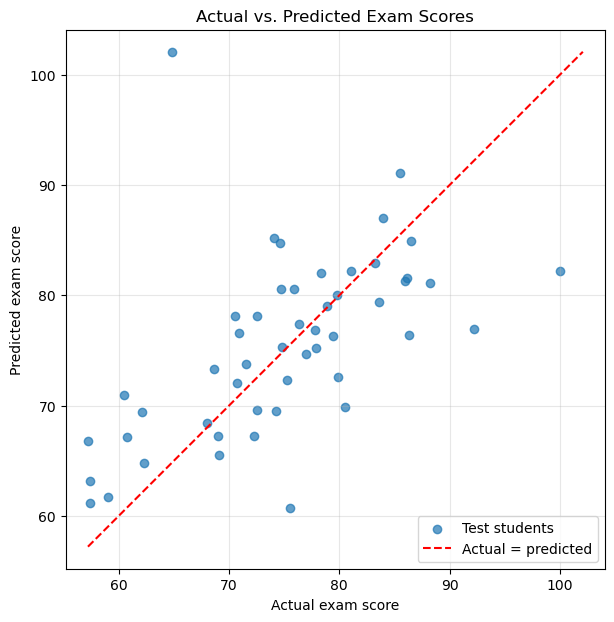

In [69]:
# Compare each test student's actual score with the model's predicted score.
plot_min = min(y_test.min(), linear_predictions.min())
plot_max = max(y_test.max(), linear_predictions.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_test, linear_predictions, alpha=0.7, label='Test students')
plt.plot([plot_min, plot_max], [plot_min, plot_max],
         color='red', linestyle='--', label='Actual = predicted')
plt.xlim(plot_min - 2, plot_max + 2)
plt.ylim(plot_min - 2, plot_max + 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Actual vs. Predicted Exam Scores')
plt.xlabel('Actual exam score')
plt.ylabel('Predicted exam score')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

A perfect model would place every point exactly on the red diagonal line: for example, a student with an actual score of 82 would have a predicted score of 82. Points above the line are overpredictions, points below it are underpredictions, and points closer to the line have smaller errors.

# Part 11 — Residual Analysis

A positive residual means the actual score was higher than predicted (under-prediction), a negative residual means it was lower (over-prediction), and a residual near zero means an accurate prediction. Apart from one outlier (predicted about 102, residual about -37), the residuals form a fairly even cloud around zero with no clear curve or funnel. That one student alone accounts for about 40% of the total squared error. With only 50 test students, a mild pattern would be hard to detect.

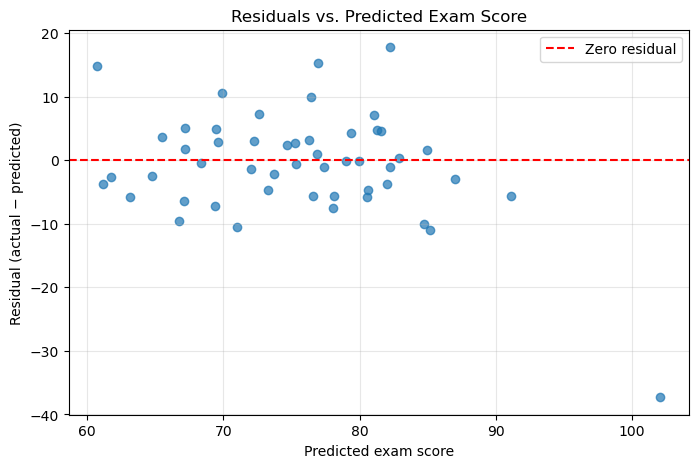

In [70]:
# y_pred contains the linear-model predictions for the test set.
y_pred = linear_predictions
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', label='Zero residual')
plt.title('Residuals vs. Predicted Exam Score')
plt.xlabel('Predicted exam score')
plt.ylabel('Residual (actual − predicted)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Part 12 — Find the Largest Errors

In [71]:
# Combine the test features with each prediction error.
test_error_analysis = X_test.copy()
test_error_analysis.insert(0, 'actual_exam_score', y_test)
test_error_analysis.insert(1, 'predicted_exam_score', y_pred)
test_error_analysis.insert(2, 'residual', y_test - y_pred)
test_error_analysis.insert(3, 'absolute_error', (y_test - y_pred).abs())

top_10_errors = test_error_analysis.sort_values('absolute_error', ascending=False).head(10)
print('Ten test students with the largest absolute prediction errors:')
print(top_10_errors.round(2))

# Reference values for forming hypotheses about the largest errors.
numeric_dataset_averages = df[numeric_features].mean().round(2)
prior_experience_proportions = df['prior_programming_experience'].value_counts(normalize=True, dropna=False).round(3)
study_group_proportions = df['study_group'].value_counts(normalize=True).round(3)

print('\nNumeric feature averages in the full dataset:')
print(numeric_dataset_averages)
print('\nPrior-programming-experience proportions in the full dataset:')
print(prior_experience_proportions)
print('\nStudy-group proportions in the full dataset:')
print(study_group_proportions)

Ten test students with the largest absolute prediction errors:
     actual_exam_score  predicted_exam_score  residual  absolute_error  \
173               64.8                102.09    -37.29           37.29   
108              100.0                 82.25     17.75           17.75   
19                92.2                 76.93     15.27           15.27   
69                75.5                 60.72     14.78           14.78   
240               74.1                 85.16    -11.06           11.06   
196               80.5                 69.91     10.59           10.59   
15                60.5                 70.98    -10.48           10.48   
222               74.6                 84.70    -10.10           10.10   
67                86.3                 76.42      9.88            9.88   
159               57.2                 66.77     -9.57            9.57   

     study_hours_per_week  sleep_hours_per_night  attendance_rate  \
173                  17.8                    6.9     

Case 1: student 173. Data show: actual 64.8, predicted 102.09 (residual -37.29), with the dataset's highest study hours (17.8, versus an average of 7.5), 98.1% attendance, 0 practice problems, and Strong experience. Hypothesis: the linear model extends the study-hours trend beyond where most of the data lie, producing an impossible prediction above 100. The 17.8-hour value could also be unusual or an entry error, or 0 practice problems matters more than the model weights it. The table doesn't establish any of these.

Case 2: student 108. Data show: actual 100, predicted 82.25 (residual +17.75), with above-average study hours (10.1), practice problems (25 vs. 16.9), and attendance (91.6), no prior experience ("None"), and a 0-minute commute. Hypothesis: the negative coefficient for "None" (-4.87) may have pulled the prediction down for a student whose other habits were strong. Or the model compresses extreme scores toward the middle. I didn't test either explanation.

Pattern worth noting: four of the ten largest errors (173, 15, 222, 159) are Strong-experience students, who are only 19.2% of the dataset, and all four were over-predicted. Three of them (173, 15, 159) reported 0 practice problems. This could suggest the model gives Strong students a boost that doesn't hold up when practice is low, but it is a hypothesis from a small sample.

# Part 13 — Examine the Linear Regression Coefficients

Positive coefficients: study hours (5.93), Strong experience (5.06), practice problems (3.17), attendance (1.98), sleep (1.33), commute (0.53), and study group No (0.12). Negative: None (-4.87), Some (-0.19), and study group Yes (-0.12). The largest in magnitude are study hours, Strong, None, and practice problems. A positive coefficient means the fitted model gives a higher predicted score to students with higher values of that feature, holding the other modeled features fixed, and it doesn't mean the feature causes the score. Numeric coefficients are per standard deviation, and the one-hot columns are only meaningful relative to each other: the model predicts Strong students about 9.9 points above None students, and the study-group pair is just a mirror image with a negligible gap.

Coefficients sorted by absolute magnitude:
                                Transformed feature  Coefficient  \
0                     numeric__study_hours_per_week        5.933   
1  categorical__prior_programming_experience_Strong        5.060   
2    categorical__prior_programming_experience_None       -4.867   
3               numeric__practice_problems_per_week        3.169   
4                          numeric__attendance_rate        1.976   
5                    numeric__sleep_hours_per_night        1.329   
6                          numeric__commute_minutes        0.528   
7    categorical__prior_programming_experience_Some       -0.192   
8                       categorical__study_group_No        0.120   
9                      categorical__study_group_Yes       -0.120   

   Absolute coefficient  
0                 5.933  
1                 5.060  
2                 4.867  
3                 3.169  
4                 1.976  
5                 1.329  
6                 0.528  


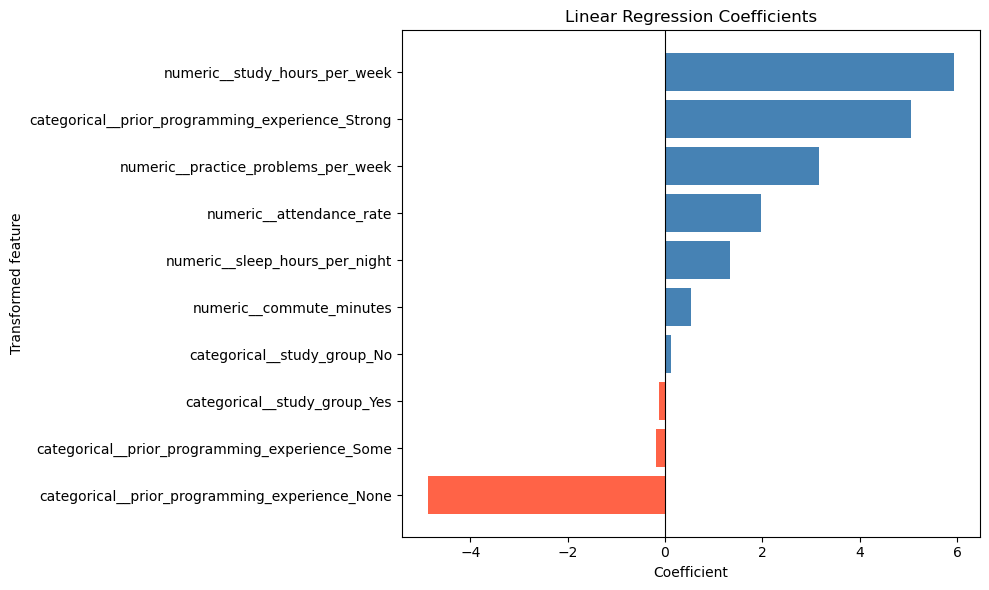

In [72]:
# Get the names created by preprocessing and pair them with fitted coefficients.
fitted_preprocessor = linear_model.named_steps['preprocessor']
fitted_regressor = linear_model.named_steps['regressor']

transformed_feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_regressor.coef_

coefficient_table = pd.DataFrame({
    'Transformed feature': transformed_feature_names,
    'Coefficient': coefficients
})
coefficient_table['Absolute coefficient'] = coefficient_table['Coefficient'].abs()
coefficient_table = coefficient_table.sort_values(
    'Absolute coefficient', ascending=False
).reset_index(drop=True)

print('Coefficients sorted by absolute magnitude:')
print(coefficient_table.round(3))

plot_coefficients = coefficient_table.sort_values('Coefficient')
bar_colors = np.where(plot_coefficients['Coefficient'] >= 0, 'steelblue', 'tomato')
plt.figure(figsize=(10, 6))
plt.barh(plot_coefficients['Transformed feature'],
         plot_coefficients['Coefficient'], color=bar_colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Transformed feature')
plt.tight_layout()
plt.show()

A coefficient is the model's estimated change in predicted exam score for a one-unit increase in that transformed feature, while the other model inputs are held fixed. Positive coefficients increase the prediction and negative coefficients decrease it. The numeric inputs were standardized, so one unit for those features means one standard deviation; one-hot categorical coefficients represent the effect of an indicator changing from 0 to 1.

Coefficients describe associations learned from this dataset, not causes. Students were not randomly assigned different study hours, attendance, or backgrounds, and unmeasured factors may affect both a feature and exam score. Correlated input features can also change coefficient sizes and signs, so these values should not be read as the isolated causal effect of changing one student characteristic.

# Part 14 — Feature Experiment: Add quiz_average

In [73]:
# Use the same train/test student rows as the original split.
features_with_quiz = features + ['quiz_average']
X_train_with_quiz = df.loc[X_train.index, features_with_quiz]
X_test_with_quiz = df.loc[X_test.index, features_with_quiz]

numeric_features_with_quiz = numeric_features + ['quiz_average']
preprocessor_with_quiz = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_features_with_quiz),
    ('categorical', categorical_pipeline, categorical_features)
])

linear_model_with_quiz = Pipeline(steps=[
    ('preprocessor', preprocessor_with_quiz),
    ('regressor', LinearRegression())
])

linear_model_with_quiz.fit(X_train_with_quiz, y_train)
quiz_predictions = linear_model_with_quiz.predict(X_test_with_quiz)

quiz_mae = mean_absolute_error(y_test, quiz_predictions)
quiz_rmse = np.sqrt(mean_squared_error(y_test, quiz_predictions))
quiz_r2 = r2_score(y_test, quiz_predictions)

model_comparison = pd.DataFrame({
    'MAE': [baseline_mae, linear_mae, quiz_mae],
    'RMSE': [baseline_rmse, linear_rmse, quiz_rmse],
    'R²': [baseline_r2, linear_r2, quiz_r2]
}, index=['Mean baseline', 'Original model', 'Model + quiz_average']).round(3)

print(model_comparison)

                        MAE   RMSE     R²
Mean baseline         7.659  9.802 -0.091
Original model        5.774  8.349  0.209
Model + quiz_average  4.749  6.231  0.559


Hypothesis (written before running): I expect adding quiz_average to reduce prediction error, because quizzes measure performance on the same course material that the final exam covers.

Results: MAE improved from 5.774 to 4.749, RMSE from 8.349 to 6.231, and R² from 0.209 to 0.559, so the hypothesis was supported on this split. With only 50 test students, I treat this as a large improvement on this split and not a general effect.

Availability: quiz_average is only a legitimate feature if the prediction is made after the quizzes but before the final exam. If the goal is an early-semester prediction, it wouldn't exist yet and including it would be leakage. A big gain in R² doesn't settle whether a feature is appropriate, because predictiveness and availability are separate questions.

# Part 15 — Random Forest

In [74]:
from sklearn.ensemble import RandomForestRegressor

# Build a separate pipeline with the same original features and preprocessing steps.
preprocessor_for_forest = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor_for_forest),
    ('regressor', RandomForestRegressor(random_state=42))
])

random_forest_model.fit(X_train, y_train)
forest_predictions = random_forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

all_model_summary = pd.DataFrame({
    'MAE': [baseline_mae, linear_mae, quiz_mae, forest_mae],
    'RMSE': [baseline_rmse, linear_rmse, quiz_rmse, forest_rmse],
    'R²': [baseline_r2, linear_r2, quiz_r2, forest_r2]
}, index=[
    'Mean baseline',
    'Linear Regression',
    'Linear Regression + quiz_average',
    'Random Forest'
]).round(3)

print(all_model_summary)

                                    MAE   RMSE     R²
Mean baseline                     7.659  9.802 -0.091
Linear Regression                 5.774  8.349  0.209
Linear Regression + quiz_average  4.749  6.231  0.559
Random Forest                     6.313  7.985  0.276


Linear Regression had the lowest MAE (5.774 vs. 6.313), while Random Forest had the lowest RMSE (7.985 vs. 8.349) and the highest R² (0.276 vs. 0.209); both beat the baseline. The more complicated model did not win on every metric, so it wasn't necessarily better. On this dataset and this particular train/test split, the two models performed similarly with a mixed picture, and the RMSE and R² gaps are small with only 50 test students. One possible explanation for the RMSE/MAE split is that Random Forest handles the large outlier better, but I haven't tested that. Cross-validation would be the proper way to compare them.

# Part 16 — Scaling

RandomForestRegressor doesn't need StandardScaler. Trees split on thresholds such as study_hours_per_week < 8.5, and standardizing changes the numeric threshold but not the order of students, so the same students end up on each side of the split. Imputation and one-hot encoding are still needed for missing and categorical values.

# Part 17 — My Experiment

Hypothesis: I expect the model's MAE to be larger for the bottom and top thirds than for the middle third, because a linear model with modest R² tends to predict near the average. I also expect negative mean residuals (over-prediction) for the bottom third and positive ones (under-prediction) for the top. Equal MAEs and no consistent residual direction would count against it.

Result: the low group (17 students, actual 57.2-71.5) had MAE 6.658 and mean residual -6.020. The middle group (16 students, 72.3-78.3) had MAE 4.946 and -0.384. The high group (17 students, 78.9-100) had MAE 5.670 and +4.486. The weighted group MAE matches the overall test MAE of 5.774.

Verdict: mostly supported. The residual directions match the hypothesis, and both extreme groups have a larger MAE than the middle. One caveat is that the low group's MAE is driven by student 173: by my rough calculation, without that student it would be about 4.7, slightly below the middle group's. Also, grouping by actual score builds in part of this pattern, since selecting extreme outcomes tends to give over-predictions at the bottom and under-predictions at the top even for an unbiased model. Each group has only 16-17 students and this is one split, so the result is tentative.

In [75]:
# Reuse the existing corrected Linear Regression test predictions; no model is refit.
score_group_analysis = pd.DataFrame({
    'actual_exam_score': y_test,
    'predicted_exam_score': linear_predictions
})
score_group_analysis['residual'] = (
    score_group_analysis['actual_exam_score']
    - score_group_analysis['predicted_exam_score']
)
score_group_analysis['absolute_error'] = score_group_analysis['residual'].abs()
score_group_analysis['score_group'] = pd.qcut(
    score_group_analysis['actual_exam_score'],
    q=3,
    labels=['low', 'middle', 'high']
)

score_group_summary = score_group_analysis.groupby(
    'score_group', observed=False
).agg(
    count=('actual_exam_score', 'size'),
    minimum_actual_score=('actual_exam_score', 'min'),
    maximum_actual_score=('actual_exam_score', 'max'),
    mean_actual_score=('actual_exam_score', 'mean'),
    mean_predicted_score=('predicted_exam_score', 'mean'),
    MAE=('absolute_error', 'mean'),
    mean_residual=('residual', 'mean')
)

weighted_group_mae = np.average(
    score_group_summary['MAE'],
    weights=score_group_summary['count']
)
overall_test_mae = mean_absolute_error(y_test, linear_predictions)

print(score_group_summary.round(3))
print(f'\nCount-weighted group MAE: {weighted_group_mae:.6f}')
print(f'Overall test MAE: {overall_test_mae:.6f}')
print('Weighted group MAE equals overall test MAE:', np.isclose(weighted_group_mae, overall_test_mae))

             count  minimum_actual_score  maximum_actual_score  \
score_group                                                      
low             17                  57.2                  71.5   
middle          16                  72.3                  78.3   
high            17                  78.9                 100.0   

             mean_actual_score  mean_predicted_score    MAE  mean_residual  
score_group                                                                 
low                     64.688                70.708  6.658         -6.020  
middle                  75.238                75.621  4.946         -0.384  
high                    84.776                80.291  5.670          4.486  

Count-weighted group MAE: 5.774014
Overall test MAE: 5.774014
Weighted group MAE equals overall test MAE: True


# Part 18 — AI Reflection

I used ChatGPT inside my notebook workflow to build the pipeline, plots, and experiments. I asked the agent for focused help one part at a time, such as a pipeline with median/most-frequent imputation, and standardization, then a Linear Regression pipeline, residual plots, a coefficient table, and a Random Forest comparison. I accepted most code after checking it myself: RMSE equals the square root of MSE, the baseline and models used the same y_test, and the baseline row stayed unchanged after I reran the notebook.

The most important thing I learned came from questioning the data, not the code. prior_programming_experience had 95 missing values (38%) while other columns had few, and my coefficient table showed only Some and Strong columns. I fixed the loading, reran everything, discarded the earlier results, and dropped an experiment that was designed around the bugged data. After the fix, the model coefficients showed a clear None < Some < Strong ordering.

I questioned several AI suggestions. The agent's Random Forest paragraph said "a lower test MAE means Random Forest performed better," but my Random Forest actually had the higher MAE, so I rewrote it around the real pattern. Its coefficient text described a one-hot coefficient as "the effect" of an indicator, which sounds causal, so I reworded it as a difference in predicted score. An early explanation also said regression could show "how much a factor changes the score," which I changed to association language. I also recomputed the weighted-MAE check when it printed False and found it was a rounding artifact.

I modified the AI's code in places: I added padding to the actual-vs-predicted plot because points were clipped, and I removed unrounded-versus-rounded comparison errors. What I learned was that a baseline gives metrics meaning, one extrapolated outlier can account for about 40% of the squared error, a feature can be predictive but unavailable at prediction time, and a result from a single 50-student test split should be stated cautiously. 


**Link to the AI Agent Chat:** https://chatgpt.com/s/cx_6ac5dc3384008191940bee27a0c2c9c6